# Exploración del dataset de siniestros viales

Este notebook documenta el análisis exploratorio utilizado antes del entrenamiento del modelo.

La exploración se divide en dos etapas:

1. **Dataset original (`data/raw`)**: se revisa el estado inicial de los datos, valores faltantes, valores `SD`, tipos de datos, duplicados y columnas disponibles. Esta parte justifica la necesidad de limpieza.
2. **Dataset limpio (`data/processed/dataset_limpio.csv`)**: se analizan las variables finales que entran al modelo, la variable objetivo `fatal` y posibles patrones asociados a los casos fatales.

> **Nota metodológica:** el dataset está a nivel **víctima**. Por eso, el modelo predice si una víctima registrada en un siniestro corresponde a un caso fatal (`1`) o no fatal (`0`). Para trabajar estrictamente a nivel accidente habría que agrupar por `id_siniestro`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# El notebook está pensado para ejecutarse desde la carpeta notebooks/.
# De todas formas, esta función intenta resolver las rutas también si se ejecuta desde la raíz del proyecto.
def buscar_archivo(rutas_candidatas):
    for ruta in rutas_candidatas:
        ruta = Path(ruta)
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        "No se encontró el archivo en las rutas esperadas:\n" +
        "\n".join(str(r) for r in rutas_candidatas)
    )

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()

RAW_PATH = buscar_archivo([
    PROJECT_ROOT / "data" / "raw" / "siniestros_viales_victimas.xlsx",
    Path("..") / "data" / "raw" / "siniestros_viales_victimas.xlsx",
    Path("data") / "raw" / "siniestros_viales_victimas.xlsx",
])

PROCESSED_PATH = buscar_archivo([
    PROJECT_ROOT / "data" / "processed" / "dataset_limpio.csv",
    Path("..") / "data" / "processed" / "dataset_limpio.csv",
    Path("data") / "processed" / "dataset_limpio.csv",
])

print("Archivo original:", RAW_PATH)
print("Archivo procesado:", PROCESSED_PATH)


Archivo original: c:\Users\Leo\Desktop\Proyecto-Final-Control-C\data\raw\siniestros_viales_victimas.xlsx
Archivo procesado: c:\Users\Leo\Desktop\Proyecto-Final-Control-C\data\processed\dataset_limpio.csv


## 1. Exploración del dataset original

Primero se carga el archivo original ubicado en `data/raw`. Esta etapa permite ver cómo vienen los datos antes de aplicar el módulo de preprocesamiento (`src/preprocessing.py`).


In [2]:
df_raw = pd.read_excel(RAW_PATH)

print(f"Filas originales: {df_raw.shape[0]:,}")
print(f"Columnas originales: {df_raw.shape[1]}")
df_raw.head()


Filas originales: 75,193
Columnas originales: 9


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0022650,2019-01-11,2019,BICICLETA,F,25,GRAVE,CICLISTA,NaN
1,LC-2019-0068291,2019-02-01,2019,BICICLETA,F,16,GRAVE,CICLISTA,NaN
2,LC-2019-0139186,2019-03-06,2019,BICICLETA,F,32,GRAVE,CICLISTA,NaN
3,LC-2019-0247839,2019-04-21,2019,BICICLETA,F,35,GRAVE,CICLISTA,NaN
4,LC-2019-0283677,2019-05-07,2019,BICICLETA,F,42,GRAVE,CICLISTA,NaN


### 1.1 Columnas originales y tipos de datos

Se revisan los tipos de datos para detectar columnas que deberían transformarse. Por ejemplo, fechas que deben convertirse a `datetime` y edades que pueden venir como texto por la presencia de valores `SD`.


In [3]:
resumen_raw = pd.DataFrame({
    "tipo_dato": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "porcentaje_nulos": (df_raw.isna().mean() * 100).round(2),
    "valores_unicos": df_raw.nunique(dropna=False)
}).sort_values("porcentaje_nulos", ascending=False)

resumen_raw


,tipo_dato,nulos,porcentaje_nulos,valores_unicos
fecha_fallecimiento_victima,str,74490,99.0700,612
id_siniestro,str,0,0.0000,65818
fecha_siniestro,str,0,0.0000,2557
modo_desplazamiento_victima,str,0,0.0000,18
anio_siniestro,int64,0,0.0000,7
sexo_victima,str,0,0.0000,3
edad_victima,object,0,0.0000,106
GRAVEdad_victima,str,0,0.0000,4
rol_victima,str,0,0.0000,9


### 1.2 Duplicados y cantidad de siniestros

El dataset contiene registros a nivel víctima. Por eso puede haber varios registros con el mismo `id_siniestro` cuando un siniestro involucra a más de una víctima.


In [4]:
duplicados_raw = df_raw.duplicated().sum()
siniestros_unicos = df_raw["id_siniestro"].nunique() if "id_siniestro" in df_raw.columns else np.nan

print(f"Duplicados exactos en dataset original: {duplicados_raw:,}")
print(f"Siniestros únicos: {siniestros_unicos:,}")
print(f"Víctimas registradas: {len(df_raw):,}")

if "id_siniestro" in df_raw.columns:
    display(
        df_raw["id_siniestro"]
        .value_counts()
        .head(10)
        .rename_axis("id_siniestro")
        .reset_index(name="cantidad_victimas")
    )


Duplicados exactos en dataset original: 1,436
Siniestros únicos: 65,818
Víctimas registradas: 75,193


,id_siniestro,cantidad_victimas
0,LC-2024-0243962,26
1,LC-2024-0666832,19
2,LC-2022-0166804,18
3,LC-2019-0188476,16
4,LC-2019-0291069,16
5,LC-2024-0644209,15
6,LC-2023-0189217,14
7,LC-2022-0479212,13
8,LC-2024-0592048,13
9,LC-2024-0657140,13


### 1.3 Valores `SD` y faltantes del dataset original

En el archivo original aparecen valores `SD`, que significan "sin dato". En el preprocesamiento se reemplazan por valores nulos (`pd.NA`) para que luego el pipeline pueda imputarlos.


In [7]:
conteo_sd = (df_raw.astype(str).eq("SD")).sum().sort_values(ascending=False)
conteo_sd = conteo_sd[conteo_sd > 0]

pd.DataFrame({
    "cantidad_SD": conteo_sd,
    "porcentaje_SD": (conteo_sd / len(df_raw) * 100).round(2)
})


,cantidad_SD,porcentaje_SD
rol_victima,60127,79.9600
modo_desplazamiento_victima,23331,31.0300
edad_victima,23296,30.9800
sexo_victima,17094,22.7300


### 1.4 Construcción de la variable objetivo

La variable objetivo `fatal` se construye a partir de `fecha_fallecimiento_victima`: si la víctima tiene fecha de fallecimiento, se considera caso fatal (`1`); si no tiene fecha, se considera no fatal (`0`).


In [8]:
df_raw_analisis = df_raw.copy()
df_raw_analisis["fatal"] = df_raw_analisis["fecha_fallecimiento_victima"].notna().astype(int)

conteo_fatal_raw = df_raw_analisis["fatal"].value_counts().sort_index()
porcentaje_fatal_raw = (df_raw_analisis["fatal"].value_counts(normalize=True).sort_index() * 100).round(4)

resumen_fatal_raw = pd.DataFrame({
    "clase": ["No fatal (0)", "Fatal (1)"],
    "cantidad": [conteo_fatal_raw.get(0, 0), conteo_fatal_raw.get(1, 0)],
    "porcentaje": [porcentaje_fatal_raw.get(0, 0), porcentaje_fatal_raw.get(1, 0)]
})

resumen_fatal_raw


,clase,cantidad,porcentaje
0,No fatal (0),74490,99.0651
1,Fatal (1),703,0.9349


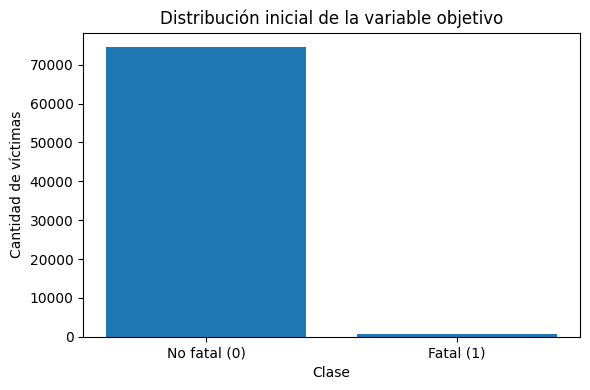

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(resumen_fatal_raw["clase"], resumen_fatal_raw["cantidad"])
plt.title("Distribución inicial de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de víctimas")
plt.tight_layout()
plt.show()


### 1.5 Revisión de la gravedad informada

El dataset original también contiene una columna de gravedad. Esta columna no se usa como variable explicativa del modelo porque está demasiado relacionada con la condición fatal y podría generar fuga de información. Se revisa solo con fines exploratorios.


,gravedad,cantidad
0,LEVE,71308
1,GRAVE,3182
2,MORTAL,703


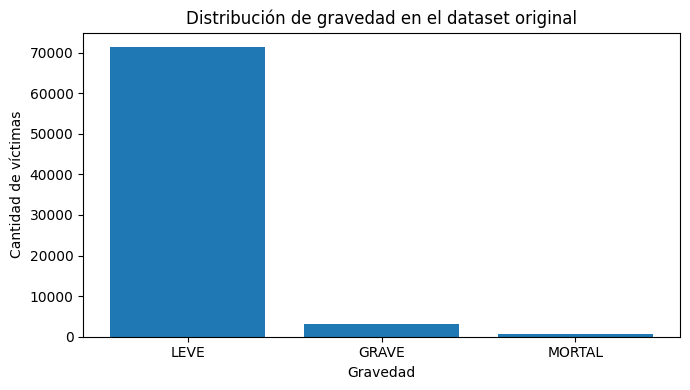

In [10]:
if "GRAVEdad_victima" in df_raw.columns:
    gravedad = (
        df_raw["GRAVEdad_victima"]
        .astype(str)
        .str.upper()
        .value_counts(dropna=False)
        .rename_axis("gravedad")
        .reset_index(name="cantidad")
    )
    display(gravedad)

    plt.figure(figsize=(7, 4))
    plt.bar(gravedad["gravedad"], gravedad["cantidad"])
    plt.title("Distribución de gravedad en el dataset original")
    plt.xlabel("Gravedad")
    plt.ylabel("Cantidad de víctimas")
    plt.tight_layout()
    plt.show()


### 1.6 Problemas detectados antes de la limpieza

Del análisis inicial se observan los siguientes puntos:

- Hay valores `SD` en variables relevantes como edad, sexo, modo de desplazamiento y rol.
- La edad viene mezclada con texto, por lo que debe convertirse a numérica.
- Las fechas deben convertirse a formato fecha para extraer año, mes y día de semana.
- El dataset está a nivel víctima, no a nivel accidente único.
- La clase fatal es minoritaria, por lo que no alcanza con mirar únicamente `accuracy`.

Estas observaciones justifican el preprocesamiento aplicado en `src/preprocessing.py`.


## 2. Carga del dataset limpio

A partir de este punto se trabaja con `data/processed/dataset_limpio.csv`, generado por el módulo de preprocesamiento. Este dataset contiene las variables finales que se usan para entrenar el modelo.


In [11]:
df = pd.read_csv(PROCESSED_PATH, low_memory=False)

print(f"Filas del dataset limpio: {df.shape[0]:,}")
print(f"Columnas del dataset limpio: {df.shape[1]}")
df.head()


Filas del dataset limpio: 75,193
Columnas del dataset limpio: 8


,anio,edad_victima,sexo_victima,modo_desplazamiento_victima,rol_victima,mes,dia_semana,fatal
0,2019,25.0000,F,BICICLETA,CICLISTA,1,4,0
1,2019,16.0000,F,BICICLETA,CICLISTA,2,4,0
2,2019,32.0000,F,BICICLETA,CICLISTA,3,2,0
3,2019,35.0000,F,BICICLETA,CICLISTA,4,6,0
4,2019,42.0000,F,BICICLETA,CICLISTA,5,1,0


## 3. Diccionario rápido de variables finales

Se revisan las columnas principales que quedaron disponibles después del preprocesamiento. Esto ayuda a justificar qué información entra al modelo y cuál es la variable objetivo.

In [10]:
diccionario = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": [str(df[col].dtype) for col in df.columns],
    "descripcion": [
        "Año del siniestro",
        "Edad de la víctima",
        "Sexo registrado de la víctima",
        "Medio o modo de desplazamiento de la víctima",
        "Rol de la víctima en el siniestro",
        "Mes del siniestro",
        "Día de la semana codificado numéricamente",
        "Variable objetivo: 1 = fatal, 0 = no fatal",
    ]
})
diccionario

,columna,tipo_dato,descripcion
0,anio,int64,Año del siniestro
1,edad_victima,float64,Edad de la víctima
2,sexo_victima,object,Sexo registrado de la víctima
3,modo_desplazamiento_victima,object,Medio o modo de desplazamiento de la víctima
4,rol_victima,object,Rol de la víctima en el siniestro
5,mes,int64,Mes del siniestro
6,dia_semana,int64,Día de la semana codificado numéricamente
7,fatal,int64,"Variable objetivo: 1 = fatal, 0 = no fatal"


## 4. Calidad general del dataset limpio

Antes de entrenar, se revisan tipos de datos, valores faltantes y duplicados. Los valores faltantes no necesariamente impiden entrenar, porque el pipeline aplica imputación, pero sí son importantes para interpretar el problema.

In [11]:
resumen_calidad = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=False)
}).sort_values("porcentaje_nulos", ascending=False)

print(f"Duplicados exactos: {df.duplicated().sum():,}")
resumen_calidad

Duplicados exactos: 28,335


,tipo,nulos,porcentaje_nulos,valores_unicos
rol_victima,object,60127,79.9600,9
edad_victima,float64,23372,31.0800,102
modo_desplazamiento_victima,object,23331,31.0300,18
sexo_victima,object,17094,22.7300,3
anio,int64,0,0.0000,7
mes,int64,0,0.0000,12
dia_semana,int64,0,0.0000,7
fatal,int64,0,0.0000,2


### Observación sobre faltantes

Las variables `rol_victima`, `edad_victima`, `modo_desplazamiento_victima` y `sexo_victima` contienen valores faltantes.  
Esto justifica el uso de un pipeline de preprocesamiento con imputación para variables numéricas y categóricas.

## 5. Distribución de la variable objetivo en el dataset limpio

La variable `fatal` define el problema de clasificación binaria. Es clave analizar su distribución porque en seguridad vial los casos fatales suelen ser minoritarios.

In [12]:
conteo_target = df["fatal"].value_counts().sort_index()
porcentaje_target = (df["fatal"].value_counts(normalize=True).sort_index() * 100).round(4)

resumen_target = pd.DataFrame({
    "clase": ["No fatal (0)", "Fatal (1)"],
    "cantidad": [conteo_target.get(0, 0), conteo_target.get(1, 0)],
    "porcentaje": [porcentaje_target.get(0, 0), porcentaje_target.get(1, 0)]
})

desbalance = conteo_target.get(0, 0) / max(conteo_target.get(1, 1), 1)
print(f"Relación aproximada no fatal / fatal: {desbalance:.1f} a 1")
resumen_target

Relación aproximada no fatal / fatal: 106.0 a 1


,clase,cantidad,porcentaje
0,No fatal (0),74490,99.0651
1,Fatal (1),703,0.9349


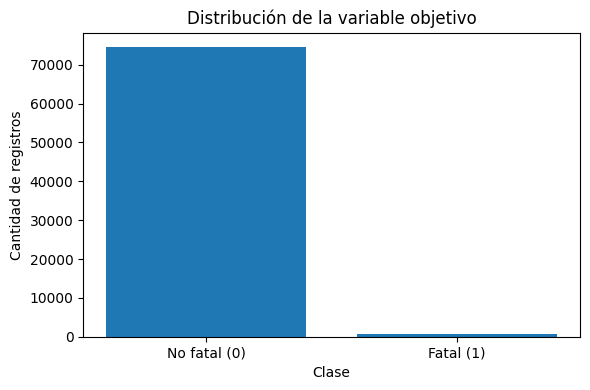

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(resumen_target["clase"], resumen_target["cantidad"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación:** el dataset está fuertemente desbalanceado. Por eso, durante la evaluación del modelo no alcanza con mirar solamente `accuracy`; también deben analizarse `recall`, `precision` y `F1-score`, especialmente para la clase fatal.

## 6. Análisis temporal

Se analiza la cantidad de registros y la tasa de fatalidad por año, mes y día de la semana. Esto permite observar si hay variaciones temporales que puedan aportar información al modelo.

In [14]:
por_anio = (
    df.groupby("anio")
      .agg(casos=("fatal", "size"), fatales=("fatal", "sum"), tasa_fatal=("fatal", "mean"))
      .reset_index()
)
por_anio["tasa_fatal_%"] = (por_anio["tasa_fatal"] * 100).round(3)
por_anio

,anio,casos,fatales,tasa_fatal,tasa_fatal_%
0,2019,11886,104,0.0087,0.8750
1,2020,6936,82,0.0118,1.1820
2,2021,9053,96,0.0106,1.0600
3,2022,10647,111,0.0104,1.0430
4,2023,11075,106,0.0096,0.9570
5,2024,12481,113,0.0091,0.9050
6,2025,13115,91,0.0069,0.6940


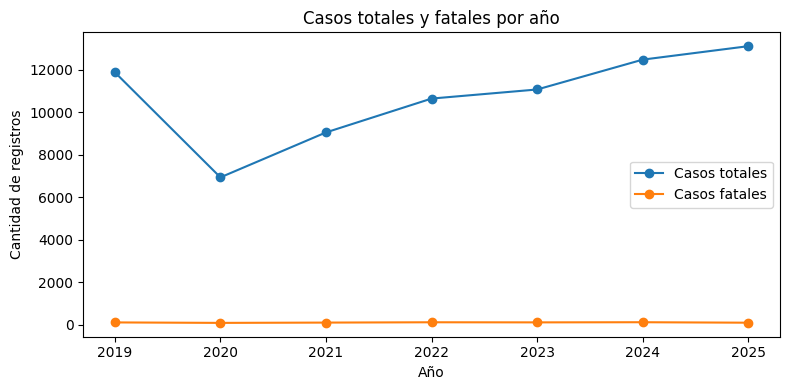

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(por_anio["anio"], por_anio["casos"], marker="o", label="Casos totales")
plt.plot(por_anio["anio"], por_anio["fatales"], marker="o", label="Casos fatales")
plt.title("Casos totales y fatales por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de registros")
plt.legend()
plt.tight_layout()
plt.show()

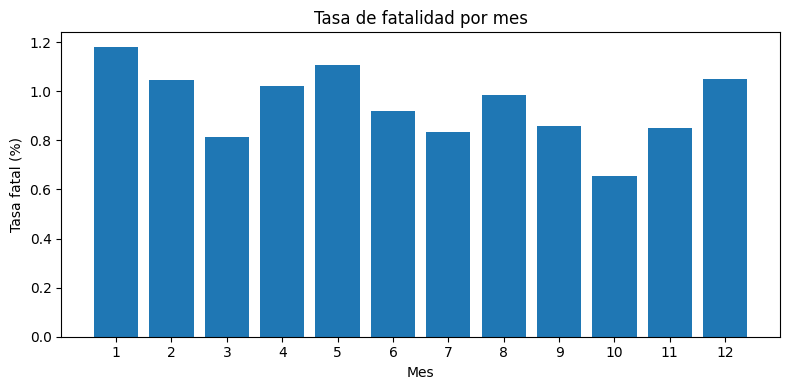

,mes,casos,fatales,tasa_fatal,tasa_fatal_%
0,1,5333,63,0.0118,1.1810
1,2,5352,56,0.0105,1.0460
2,3,6505,53,0.0081,0.8150
3,4,5982,61,0.0102,1.0200
4,5,6061,67,0.0111,1.1050
5,6,6092,56,0.0092,0.9190
6,7,6345,53,0.0084,0.8350
7,8,6509,64,0.0098,0.9830
8,9,6415,55,0.0086,0.8570
9,10,7182,47,0.0065,0.6540


In [16]:
por_mes = (
    df.groupby("mes")
      .agg(casos=("fatal", "size"), fatales=("fatal", "sum"), tasa_fatal=("fatal", "mean"))
      .reset_index()
)
por_mes["tasa_fatal_%"] = (por_mes["tasa_fatal"] * 100).round(3)

plt.figure(figsize=(8, 4))
plt.bar(por_mes["mes"], por_mes["tasa_fatal_%"])
plt.title("Tasa de fatalidad por mes")
plt.xlabel("Mes")
plt.ylabel("Tasa fatal (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

por_mes

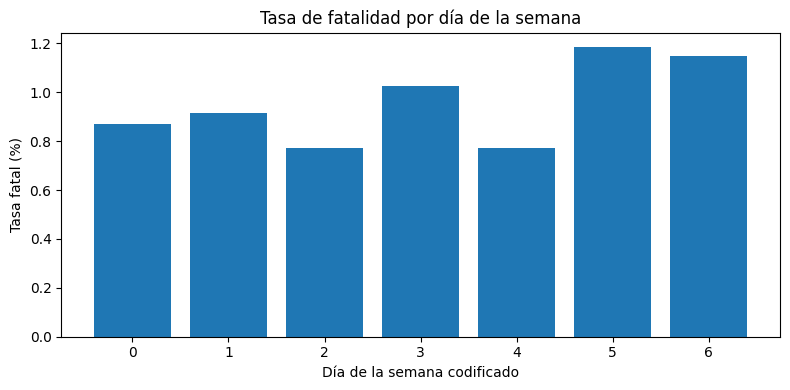

,dia_semana,casos,fatales,tasa_fatal,tasa_fatal_%
0,0,11050,96,0.0087,0.8690
1,1,11692,107,0.0092,0.9150
2,2,11641,90,0.0077,0.7730
3,3,12081,124,0.0103,1.0260
4,4,12560,97,0.0077,0.7720
5,5,9038,107,0.0118,1.1840
6,6,7131,82,0.0115,1.1500


In [17]:
por_dia = (
    df.groupby("dia_semana")
      .agg(casos=("fatal", "size"), fatales=("fatal", "sum"), tasa_fatal=("fatal", "mean"))
      .reset_index()
)
por_dia["tasa_fatal_%"] = (por_dia["tasa_fatal"] * 100).round(3)

plt.figure(figsize=(8, 4))
plt.bar(por_dia["dia_semana"].astype(str), por_dia["tasa_fatal_%"])
plt.title("Tasa de fatalidad por día de la semana")
plt.xlabel("Día de la semana codificado")
plt.ylabel("Tasa fatal (%)")
plt.tight_layout()
plt.show()

por_dia

## 5. Análisis de edad

Se analiza la edad porque puede estar relacionada con el tipo de movilidad, la exposición al riesgo y la gravedad del siniestro.

In [18]:
edad_resumen = df["edad_victima"].describe().to_frame("edad_victima")
edad_resumen

,edad_victima
count,51821.0000
mean,37.9400
std,15.8152
min,0.0000
25%,26.0000
50%,35.0000
75%,47.0000
max,116.0000


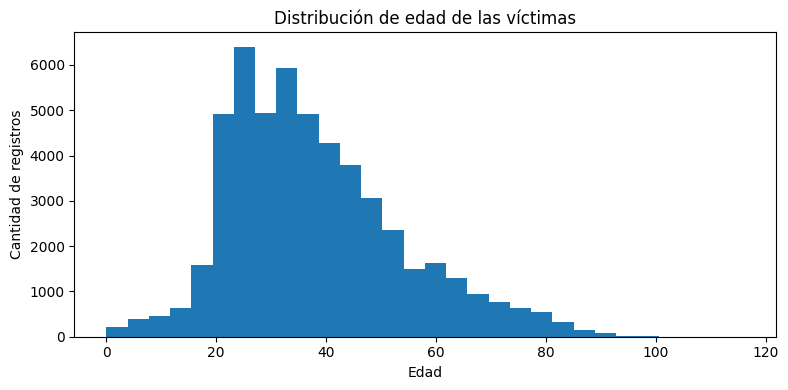

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df["edad_victima"].dropna(), bins=30)
plt.title("Distribución de edad de las víctimas")
plt.xlabel("Edad")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

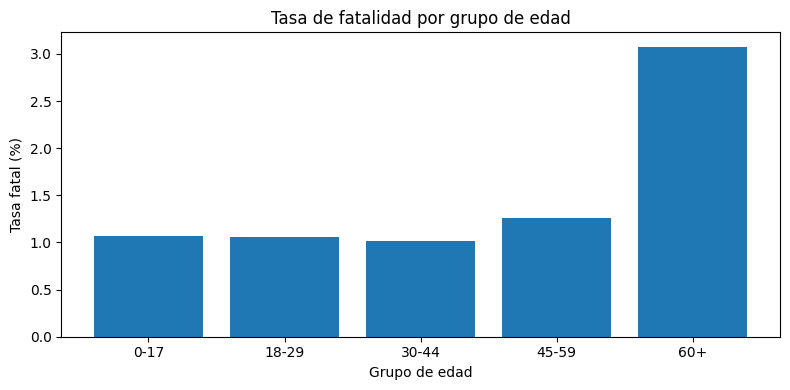

,grupo_edad,casos,fatales,tasa_fatal,tasa_fatal_%
0,0-17,2153,23,0.0107,1.0680
1,18-29,15780,167,0.0106,1.0580
2,30-44,18815,192,0.0102,1.0200
3,45-59,9544,120,0.0126,1.2570
4,60+,5529,170,0.0307,3.0750


In [20]:
bins = [0, 17, 29, 44, 59, 120]
labels = ["0-17", "18-29", "30-44", "45-59", "60+"]

df_edad = df.copy()
df_edad["grupo_edad"] = pd.cut(df_edad["edad_victima"], bins=bins, labels=labels, include_lowest=True)

por_edad = (
    df_edad.dropna(subset=["grupo_edad"])
           .groupby("grupo_edad", observed=True)
           .agg(casos=("fatal", "size"), fatales=("fatal", "sum"), tasa_fatal=("fatal", "mean"))
           .reset_index()
)
por_edad["tasa_fatal_%"] = (por_edad["tasa_fatal"] * 100).round(3)

plt.figure(figsize=(8, 4))
plt.bar(por_edad["grupo_edad"].astype(str), por_edad["tasa_fatal_%"])
plt.title("Tasa de fatalidad por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Tasa fatal (%)")
plt.tight_layout()
plt.show()

por_edad

## 8. Variables categóricas

Se revisan las categorías principales. Para evitar conclusiones engañosas, se muestran tanto cantidades de casos como tasa de fatalidad.

In [21]:
def resumen_categorica(dataframe, columna, top_n=10):
    tabla = (
        dataframe.groupby(columna, dropna=False)
                 .agg(casos=("fatal", "size"), fatales=("fatal", "sum"), tasa_fatal=("fatal", "mean"))
                 .reset_index()
    )
    tabla["tasa_fatal_%"] = (tabla["tasa_fatal"] * 100).round(3)
    tabla = tabla.sort_values("casos", ascending=False).head(top_n)
    return tabla

resumen_sexo = resumen_categorica(df, "sexo_victima")
resumen_sexo

,sexo_victima,casos,fatales,tasa_fatal,tasa_fatal_%
1,M,38221,524,0.0137,1.3710
0,F,19878,178,0.0090,0.8950
2,NaN,17094,1,0.0001,0.0060


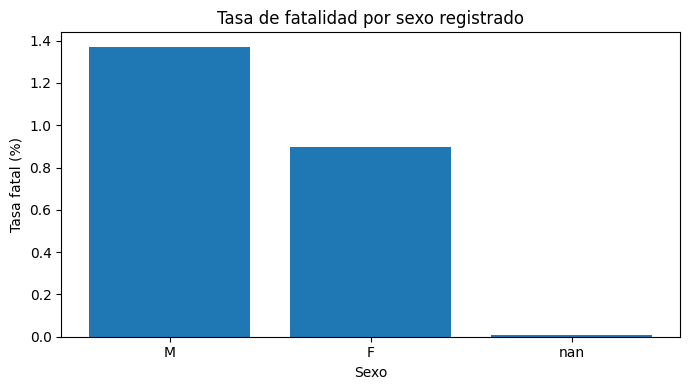

In [22]:
plt.figure(figsize=(7, 4))
plt.bar(resumen_sexo["sexo_victima"].astype(str), resumen_sexo["tasa_fatal_%"])
plt.title("Tasa de fatalidad por sexo registrado")
plt.xlabel("Sexo")
plt.ylabel("Tasa fatal (%)")
plt.tight_layout()
plt.show()

In [23]:
resumen_modo = resumen_categorica(df, "modo_desplazamiento_victima", top_n=12)
resumen_modo

,modo_desplazamiento_victima,casos,fatales,tasa_fatal,tasa_fatal_%
17,NaN,23331,0,0.0000,0.0000
5,MOTO,22616,289,0.0128,1.2780
8,PEATON,8405,275,0.0327,3.2720
0,AUTO,7737,61,0.0079,0.7880
1,BICICLETA,6281,54,0.0086,0.8600
10,TRANSPORTE PUBLICO,3880,6,0.0015,0.1550
11,UTILITARIO,809,8,0.0099,0.9890
9,TAXI,779,1,0.0013,0.1280
6,MOVIL,492,3,0.0061,0.6100
2,CAMION,246,5,0.0203,2.0330


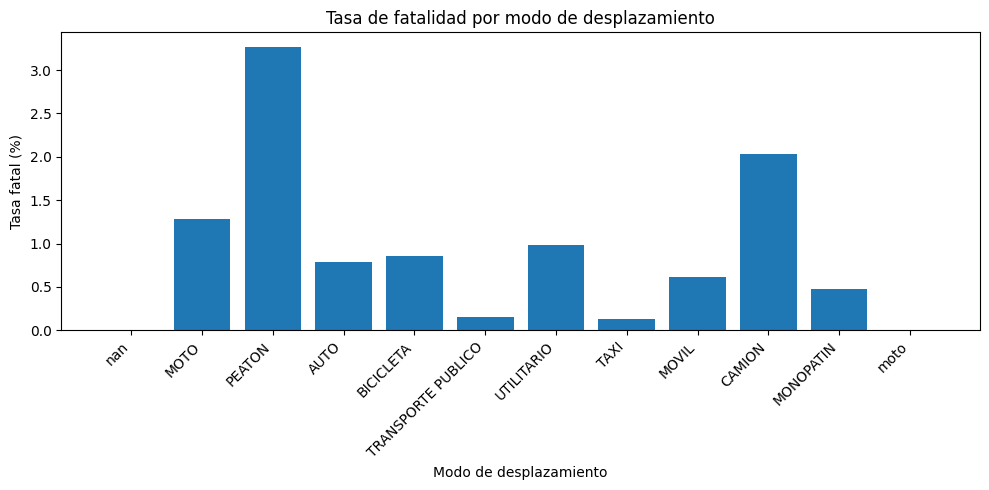

In [24]:
plt.figure(figsize=(10, 5))
plt.bar(resumen_modo["modo_desplazamiento_victima"].astype(str), resumen_modo["tasa_fatal_%"])
plt.title("Tasa de fatalidad por modo de desplazamiento")
plt.xlabel("Modo de desplazamiento")
plt.ylabel("Tasa fatal (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
# Normalización solo exploratoria para ver mejor categorías repetidas con distinto formato.
df_roles = df.copy()
df_roles["rol_victima_normalizado"] = (
    df_roles["rol_victima"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({"SD": pd.NA, "NAN": pd.NA})
)

resumen_rol = resumen_categorica(df_roles, "rol_victima_normalizado", top_n=10)
resumen_rol

,rol_victima_normalizado,casos,fatales,tasa_fatal,tasa_fatal_%
4,<NA>,60136,3,0.0000,0.0050
3,PEATON,8405,275,0.0327,3.2720
0,CICLISTA,6281,54,0.0086,0.8600
1,CONDUCTOR,307,307,1.0000,100.0000
2,PASAJERO,64,64,1.0000,100.0000


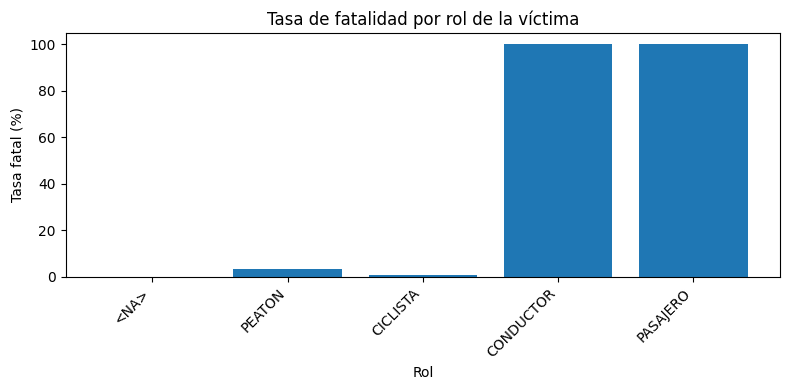

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(resumen_rol["rol_victima_normalizado"].astype(str), resumen_rol["tasa_fatal_%"])
plt.title("Tasa de fatalidad por rol de la víctima")
plt.xlabel("Rol")
plt.ylabel("Tasa fatal (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Relación entre variables numéricas y target

Se revisa una matriz de correlación simple para las variables numéricas. En problemas reales esta matriz no explica todo el fenómeno, pero ayuda a tener una primera lectura de relaciones lineales.

In [27]:
numericas = df.select_dtypes(include=["number"])
corr = numericas.corr(numeric_only=True).round(3)
corr

,anio,edad_victima,mes,dia_semana,fatal
anio,1.0000,0.0130,0.0480,0.0060,-0.0080
edad_victima,0.0130,1.0000,-0.0240,-0.0360,0.0520
mes,0.0480,-0.0240,1.0000,-0.0010,-0.0070
dia_semana,0.0060,-0.0360,-0.0010,1.0000,0.0080
fatal,-0.0080,0.0520,-0.0070,0.0080,1.0000


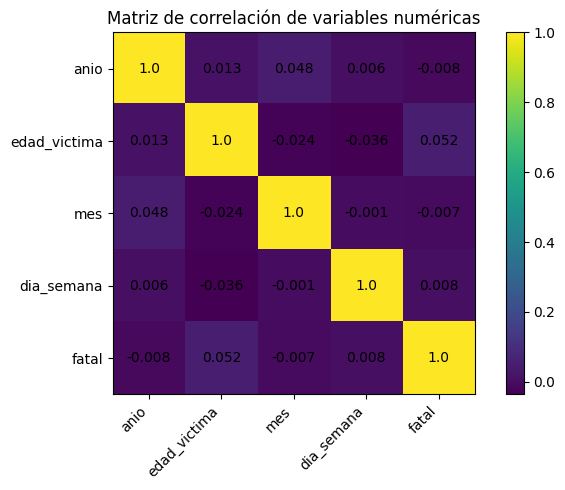

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center")

plt.title("Matriz de correlación de variables numéricas")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 8. Hallazgos principales del EDA

- El dataset contiene muchas más víctimas **no fatales** que **fatales**, por lo que existe un desbalance marcado de clases.
- El desbalance justifica evaluar el modelo con `recall`, `precision` y `F1-score`, además de `accuracy`.
- Algunas variables relevantes tienen valores faltantes, especialmente `rol_victima`, `edad_victima`, `modo_desplazamiento_victima` y `sexo_victima`.
- Las variables temporales (`anio`, `mes`, `dia_semana`) permiten analizar variaciones en cantidad de registros y tasa de fatalidad.
- La edad, el modo de desplazamiento y el rol de la víctima pueden aportar información útil para el modelo.
- El notebook confirma la necesidad de usar un pipeline con imputación, escalado/transformación de variables numéricas y codificación de variables categóricas.

Este análisis exploratorio sirve como paso previo al entrenamiento y permite justificar las decisiones tomadas en los scripts de `preprocessing.py`, `train.py` y `evaluate.py`.